In [1]:
import numpy as np
import matplotlib.pyplot as plt

=== HASIL STUDI KASUS 1 ===
Data Acuan  : T0 = 100.0°C, h0 = 2675.5 kJ/kg | T1 = 150.0°C, h1 = 2693.1 kJ/kg
Hasil Pada Target T = 120.0°C adalah h = 2682.54 kJ/kg


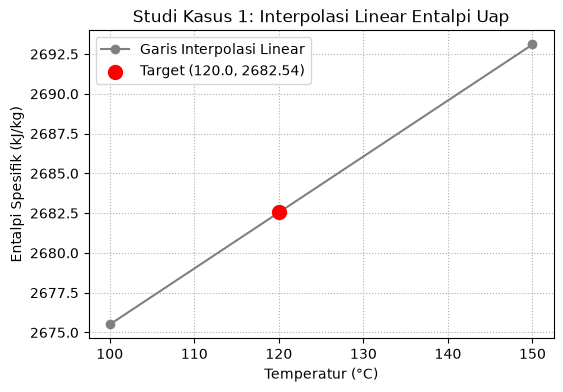

In [2]:
# STUDI KASUS 1: INTERPOLASI LINEAR (Tabel Uap Termodinamika)
# 1. Definisikan Titik Data Acuan
x0, y0 = 100.0, 2675.5
x1, y1 = 150.0, 2693.1

# Nilai temperatur target yang dicari
x_target1 = 120.0

# 2. Rumus Eksplisit Interpolasi Linear
y_pred1 = y0 + ((y1 - y0) / (x1 - x0)) * (x_target1 - x0)

print("=== HASIL STUDI KASUS 1 ===")
print(f"Data Acuan  : T0 = {x0}°C, h0 = {y0} kJ/kg | T1 = {x1}°C, h1 = {y1} kJ/kg")
print(f"Hasil Pada Target T = {x_target1}°C adalah h = {y_pred1:.2f} kJ/kg")

# 3. Visualisasi Grafik Linear
plt.figure(figsize=(6, 4))
plt.plot([x0, x1], [y0, y1], color='gray', linestyle='-', marker='o', label='Garis Interpolasi Linear')
plt.scatter(x_target1, y_pred1, color='red', s=100, zorder=5, label=f'Target ({x_target1}, {y_pred1:.2f})')
plt.title('Studi Kasus 1: Interpolasi Linear Entalpi Uap')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Entalpi Spesifik (kJ/kg)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

=== HASIL STUDI KASUS 2 ===
Koefisien Newton: b0 = 200.0, b1 = -6.5, b2 = 0.1125
Estimasi Viskositas pada T = 30.0°C adalah = 123.75 mPa.s


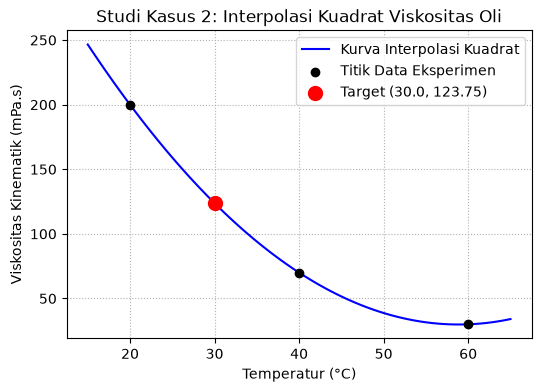

In [3]:
# STUDI KASUS 2: INTERPOLASI KUADRAT (Viskositas Oli Mesin)
# 1. Definisikan Data Acuan (3 Titik)
x_oli = np.array([20.0, 40.0, 60.0])
y_oli = np.array([200.0, 70.0, 30.0])
x_target2 = 30.0

# 2. Hitung Koefisien Polinomial Newton (Divided Differences)
b0 = y_oli[0]
b1 = (y_oli[1] - y_oli[0]) / (x_oli[1] - x_oli[0])

# Komponen pembilang untuk b2 (Gradien Kanan - Gradien Kiri)
gradien_kanan = (y_oli[2] - y_oli[1]) / (x_oli[2] - x_oli[1])
b2 = (gradien_kanan - b1) / (x_oli[2] - x_oli[0])

# 3. Hitung Nilai Prediksi pada Target Orde 2
y_pred2 = b0 + b1*(x_target2 - x_oli[0]) + b2*(x_target2 - x_oli[0])*(x_target2 - x_oli[1])

print("=== HASIL STUDI KASUS 2 ===")
print(f"Koefisien Newton: b0 = {b0}, b1 = {b1}, b2 = {b2}")
print(f"Estimasi Viskositas pada T = {x_target2}°C adalah = {y_pred2:.2f} mPa.s")

# 4. Visualisasi Grafik Kuadrat (Parabola)
x_kurva = np.linspace(15, 65, 100)
# Hitung nilai y pada kurva mulus kontinu
y_kurva = b0 + b1*(x_kurva - x_oli[0]) + b2*(x_kurva - x_oli[0])*(x_kurva - x_oli[1])

plt.figure(figsize=(6, 4))
plt.plot(x_kurva, y_kurva, color='blue', linestyle='-', label='Kurva Interpolasi Kuadrat')
plt.scatter(x_oli, y_oli, color='black', label='Titik Data Eksperimen', zorder=4)
plt.scatter(x_target2, y_pred2, color='red', s=100, zorder=5, label=f'Target ({x_target2}, {y_pred2:.2f})')
plt.title('Studi Kasus 2: Interpolasi Kuadrat Viskositas Oli')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Viskositas Kinematik (mPa.s)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()